<a href="https://colab.research.google.com/github/iasolb/ECON3916-Statistics-MachineLearning/blob/main/Assignment%202/Econ_3916_Assignment_2_Audit_IanSolberg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 - The Algorithmic Audit | ECON3916

Ian Solberg
Feb 9, 2026


#### Description:

The Mission: You are a Data Quality Auditor at Pareto Ventures, a Series B VC firm. Your Managing Partner has handed you due diligence dossiers on three potential portfolio companies. Each claims to have "perfect" metrics: stable servers, accurate AI, and successful A/B tests.

Your job is to find the statistical lie hidden in their averages. You will transition from a builder of metrics to a forensic auditor of algorithms.

### Step 1.1: The "Latency" Trap

The Pitch: "NebulaCloud" claims a Mean Latency of 35ms.

The Reality: In a "Pareto World," the mean is a vanity metric. You suspect tail latency is high.

Task: Simulate the Data Generating Process (DGP) for a skewed system. Create a numpy array latency_logs with 1,000 requests:

- 980 "Normal" requests: Random integers between 20ms–50ms.

- 20 "Spike" requests: Random integers between 1000ms–5000ms

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])

### Step 1.2: Manual MAD vs. SD

Task: Write a function calculate_mad(data) from scratch to prove the stability of robust statistics.

*Constraint: Do NOT use scipy.stats. You must perform the vector subtraction and median calculation manually using numpy.*

In [4]:
def calculate_mad(data:np.array) -> float:
    # 1. Calculate the Median of the data
    median = np.median(data)
    # 2. Calculate Absolute Deviations (|x - median|)
    deviations = np.abs(data - median)
    # 3. Return the Median of those deviations
    return np.median(deviations)

median_absolute_deviation = calculate_mad(latency_logs)
std = np.std(latency_logs)
print(f"Standard Deviation: {std} \n Median Absolute Deviation: {median_absolute_deviation}")

Standard Deviation: 415.27615058416245 
 Median Absolute Deviation: 8.0


Analysis: Compare the Standard Deviation (SD) vs. MAD. Explain why the SD is "exploded" by the 20 outliers while the MAD remains stable.

### Response:



### Step 2.1: The False Positive Paradox

The Pitch: "IntegrityAI" claims their plagiarism detector is 98% Accurate (Sensitivity=98%, Specificity=98%).

The Reality: In an Honors Seminar, cheating is rare (Base Rate = 0.1%).

Task: Write a function `bayesian_audit(prior, sensitivity, specificity):` that calculates the Posterior Probability: $P(Cheater | Flagged)$.

---
Scenarios to Test:

- Scenario A (Bootcamp): Base Rate = 50%
- Scenario B (Econ Class): Base Rate = 5%
- Scenario C (Honors Seminar): Base Rate = 0.1%

In [ ]:
def bayesian_audit(prior:float, sensitivity:float, specificity:float) -> float:


### Step 3.1: Detecting Sample Ratio Mismatch (SRM)

The Pitch: "FinFlash" ran an A/B test with 100,000 users (50/50 split). They claim a huge win.

The Data: Control Users = 50,250 | Treatment Users = 49,750.

Task: The "missing" 500 users in Treatment are suspicious. Did the app crash? Perform a Chi-Square Goodness of Fit Test manually.

# Chi-Square Formula:
$$Sum( \frac{Observed - (Expected)^2}{Expected})$$

Write the calculation loop...

*If the Chi-Square statistic > 3.84 (p < 0.05), the experiment is INVALID due to engineering bias.*

In [10]:
def chi_square_test(observed:np.array, expected:np.array) -> float:
  csqr = 0
  for i in range(len(observed)):
      csqr += (observed[i] - expected[i])**2 / expected[i]
  return csqr

"""
The Pitch: "FinFlash" ran an A/B test with 100,000 users (50/50 split). They claim a huge win.

The Data: Control Users = 50,250 | Treatment Users = 49,750.

Task: The "missing" 500 users in Treatment are suspicious. Did the app crash? Perform a Chi-Square Goodness of Fit Test manually.
"""

result = chi_square_test([49750], [50000])
print(f"Chi-Square Statistic: {result}")
if result > 3.84:
  print("The experiment is INVALID due to engineering bias.")
else:
  print("The experiment is VALID.")

Chi-Square Statistic: 1.25
The experiment is VALID.


### Task 4.1: The "Memecoin Graveyard" Simulation

The Problem: Financial data often deletes failures (Survivorship Bias). On platforms like Pump.fun, 98.6% of tokens fail. Analyzing only "Listed Coins" is a statistical lie.

Prompt:

"""
"I need to visualize Survivorship Bias in crypto markets.

(P)rep: Act as a Financial Data Scientist.

(R)equest: Write a Python script to simulate 10,000 token launches.

(I)terate:

   - Assign 'Peak Market Cap' using a Pareto Distribution (Power Law) where 99% are near zero.

   - Create two DataFrames: 'df_all' (The Graveyard) and 'df_survivors' (Top 1% only).

(M)echanism: Use numpy for distributions and matplotlib for dual histograms.

(E)valuate: Calculate and print the 'Mean Market Cap' for both groups to show the bias."
"""

  SURVIVORSHIP BIAS IN CRYPTO MARKETS  –  SIMULATION RESULTS
  Tokens simulated : 10,000
  Pareto α (shape) : 1.16
  Minimum cap      : $500
  Survivor cutoff  : top 1%  (≥ $22,662)
------------------------------------------------------------------

  ▸ All Tokens (The Graveyard + Survivors)  (n = 10,000)
      Mean Market Cap   : $         2,383
      Median Market Cap : $           897
      Max Market Cap    : $       573,676
      Min Market Cap    : $           500

  ▸ The Graveyard (Bottom 99%)  (n = 9,900)
      Mean Market Cap   : $         1,654
      Median Market Cap : $           890
      Max Market Cap    : $        22,661
      Min Market Cap    : $           500

  ▸ Survivors (Top 1%)  (n = 100)
      Mean Market Cap   : $        74,541
      Median Market Cap : $        45,753
      Max Market Cap    : $       573,676
      Min Market Cap    : $        22,697

  ⚠  BIAS FACTOR : Survivor mean is 45.1× the Graveyard mean


/tmp/ipykernel_450/839608035.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.94])


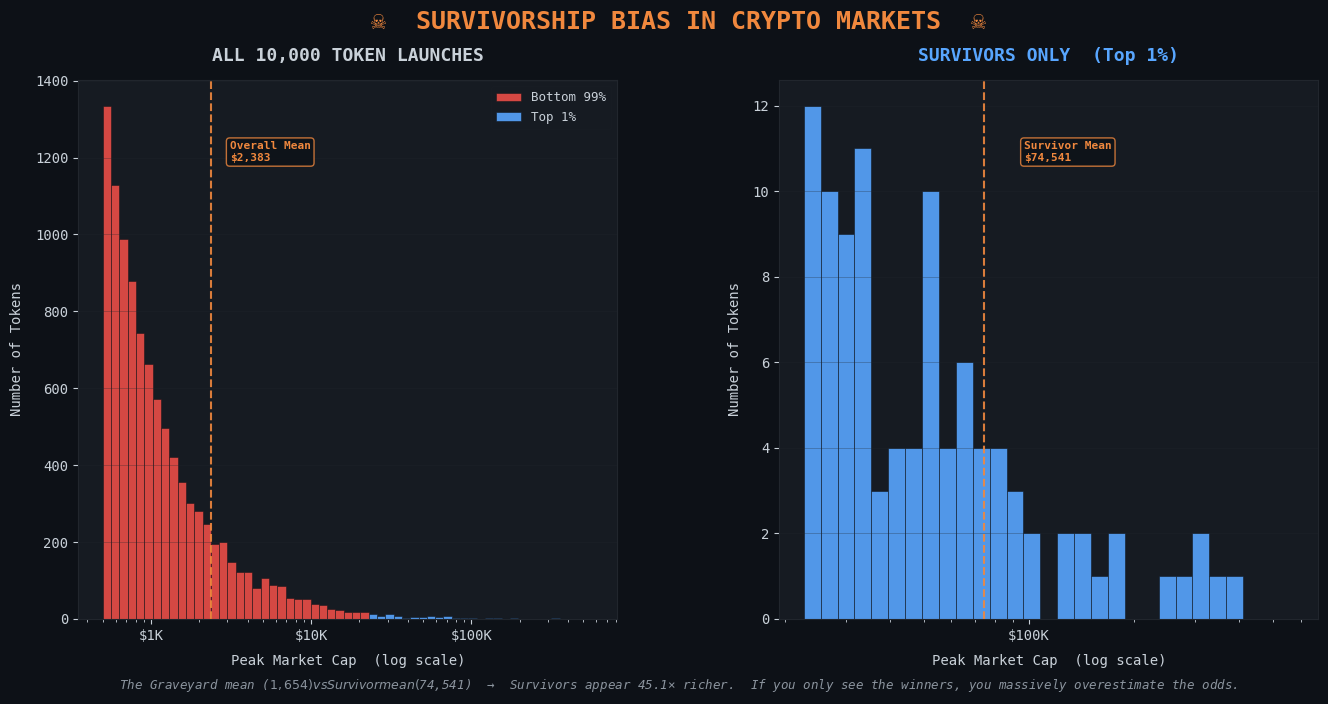

In [12]:
"""
Survivorship Bias in Crypto Markets
====================================
Simulates 10,000 token launches using a Pareto (Power Law) distribution
to demonstrate how the visible "survivors" wildly distort our perception
of typical crypto market outcomes.

Author: Financial Data Scientist Simulation
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch

# ──────────────────────────────────────────────
# 1. SIMULATION PARAMETERS
# ──────────────────────────────────────────────
np.random.seed(42)

N_TOKENS = 10_000
PARETO_ALPHA = 1.16          # shape – lower = heavier tail
X_MIN = 500                  # minimum peak market cap ($500)
SURVIVOR_PERCENTILE = 99     # top 1% = survivors

# ──────────────────────────────────────────────
# 2. GENERATE PEAK MARKET CAPS  (Pareto / Power Law)
# ──────────────────────────────────────────────
# numpy's pareto returns samples from Pareto II (Lomax).
# To get Pareto I:  x = x_min * (1 + lomax_sample)
raw = (np.random.pareto(PARETO_ALPHA, N_TOKENS) + 1) * X_MIN

# ──────────────────────────────────────────────
# 3. BUILD DATAFRAMES
# ──────────────────────────────────────────────
df_all = pd.DataFrame({
    "token_id": np.arange(1, N_TOKENS + 1),
    "peak_market_cap": raw
})

cutoff = np.percentile(raw, SURVIVOR_PERCENTILE)

df_survivors = df_all[df_all["peak_market_cap"] >= cutoff].copy()
df_graveyard = df_all[df_all["peak_market_cap"] < cutoff].copy()

# ──────────────────────────────────────────────
# 4. STATISTICS
# ──────────────────────────────────────────────
stats = {
    "All Tokens (The Graveyard + Survivors)": df_all["peak_market_cap"],
    "The Graveyard (Bottom 99%)":             df_graveyard["peak_market_cap"],
    "Survivors (Top 1%)":                     df_survivors["peak_market_cap"],
}

print("=" * 66)
print("  SURVIVORSHIP BIAS IN CRYPTO MARKETS  –  SIMULATION RESULTS")
print("=" * 66)
print(f"  Tokens simulated : {N_TOKENS:,}")
print(f"  Pareto α (shape) : {PARETO_ALPHA}")
print(f"  Minimum cap      : ${X_MIN:,}")
print(f"  Survivor cutoff  : top {100 - SURVIVOR_PERCENTILE}%  (≥ ${cutoff:,.0f})")
print("-" * 66)

for label, series in stats.items():
    print(f"\n  ▸ {label}  (n = {len(series):,})")
    print(f"      Mean Market Cap   : ${series.mean():>14,.0f}")
    print(f"      Median Market Cap : ${series.median():>14,.0f}")
    print(f"      Max Market Cap    : ${series.max():>14,.0f}")
    print(f"      Min Market Cap    : ${series.min():>14,.0f}")

bias_ratio = df_survivors["peak_market_cap"].mean() / df_graveyard["peak_market_cap"].mean()
print("\n" + "=" * 66)
print(f"  ⚠  BIAS FACTOR : Survivor mean is {bias_ratio:,.1f}× the Graveyard mean")
print("=" * 66)

# ──────────────────────────────────────────────
# 5. VISUALIZATION  –  DUAL LOG-SCALE HISTOGRAMS
# ──────────────────────────────────────────────

# ── colour palette ──
BG        = "#0d1117"
PANEL_BG  = "#161b22"
GRID_CLR  = "#21262d"
TEXT_CLR  = "#c9d1d9"
GRAVE_CLR = "#f85149"     # red  – the graveyard
SURV_CLR  = "#58a6ff"     # blue – survivors
ACCENT    = "#f0883e"     # orange highlight

plt.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     PANEL_BG,
    "axes.edgecolor":     GRID_CLR,
    "axes.labelcolor":    TEXT_CLR,
    "xtick.color":        TEXT_CLR,
    "ytick.color":        TEXT_CLR,
    "text.color":         TEXT_CLR,
    "grid.color":         GRID_CLR,
    "grid.alpha":         0.4,
    "font.family":        "monospace",
    "font.size":          10,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"wspace": 0.30})

# ── shared log-spaced bins ──
log_min = np.log10(raw.min())
log_max = np.log10(raw.max())
bins = np.logspace(log_min, log_max, 60)

# ── LEFT PANEL : The Graveyard (all 10,000) ──
ax1 = axes[0]
ax1.hist(df_graveyard["peak_market_cap"], bins=bins, color=GRAVE_CLR,
         alpha=0.85, edgecolor="#0d1117", linewidth=0.4, label="Bottom 99%")
ax1.hist(df_survivors["peak_market_cap"], bins=bins, color=SURV_CLR,
         alpha=0.90, edgecolor="#0d1117", linewidth=0.4, label="Top 1%")

ax1.set_xscale("log")
ax1.set_title("ALL 10,000 TOKEN LAUNCHES", fontsize=13, fontweight="bold",
              pad=14, color=TEXT_CLR)
ax1.set_xlabel("Peak Market Cap  (log scale)", fontsize=10, labelpad=8)
ax1.set_ylabel("Number of Tokens", fontsize=10, labelpad=8)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e6:.0f}M" if x >= 1e6 else (f"${x/1e3:.0f}K" if x >= 1e3 else f"${x:.0f}")
))
ax1.legend(loc="upper right", framealpha=0.15, edgecolor=GRID_CLR,
           fontsize=9, facecolor=PANEL_BG)
ax1.grid(axis="y", linewidth=0.5)

# mean line
ax1.axvline(df_all["peak_market_cap"].mean(), color=ACCENT, ls="--", lw=1.5, alpha=0.9)
ax1.text(df_all["peak_market_cap"].mean() * 1.3,
         ax1.get_ylim()[1] * 0.85,
         f"Overall Mean\n${df_all['peak_market_cap'].mean():,.0f}",
         fontsize=8, color=ACCENT, fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3", fc=BG, ec=ACCENT, alpha=0.8))

# ── RIGHT PANEL : Survivors Only ──
ax2 = axes[1]
surv_bins = np.logspace(np.log10(df_survivors["peak_market_cap"].min()),
                        np.log10(df_survivors["peak_market_cap"].max()), 30)
ax2.hist(df_survivors["peak_market_cap"], bins=surv_bins, color=SURV_CLR,
         alpha=0.90, edgecolor="#0d1117", linewidth=0.4)

ax2.set_xscale("log")
ax2.set_title("SURVIVORS ONLY  (Top 1%)", fontsize=13, fontweight="bold",
              pad=14, color=SURV_CLR)
ax2.set_xlabel("Peak Market Cap  (log scale)", fontsize=10, labelpad=8)
ax2.set_ylabel("Number of Tokens", fontsize=10, labelpad=8)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e6:.0f}M" if x >= 1e6 else (f"${x/1e3:.0f}K" if x >= 1e3 else f"${x:.0f}")
))
ax2.grid(axis="y", linewidth=0.5)

# survivor mean line
ax2.axvline(df_survivors["peak_market_cap"].mean(), color=ACCENT, ls="--", lw=1.5, alpha=0.9)
ax2.text(df_survivors["peak_market_cap"].mean() * 1.3,
         ax2.get_ylim()[1] * 0.85,
         f"Survivor Mean\n${df_survivors['peak_market_cap'].mean():,.0f}",
         fontsize=8, color=ACCENT, fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3", fc=BG, ec=ACCENT, alpha=0.8))

# ── SUPTITLE ──
fig.suptitle("☠  SURVIVORSHIP BIAS IN CRYPTO MARKETS  ☠",
             fontsize=18, fontweight="bold", color=ACCENT, y=0.98)

# ── BOTTOM ANNOTATION ──
note = (
    f"The Graveyard mean (${df_graveyard['peak_market_cap'].mean():,.0f}) vs "
    f"Survivor mean (${df_survivors['peak_market_cap'].mean():,.0f})  →  "
    f"Survivors appear {bias_ratio:,.1f}× richer.  "
    "If you only see the winners, you massively overestimate the odds."
)
fig.text(0.5, 0.01, note, ha="center", fontsize=9, color="#8b949e",
         style="italic")

plt.tight_layout(rect=[0, 0.04, 1, 0.94])